# ML Pipeline Baseline — Replication & Evaluation

This notebook has two goals:

1. **Faithful replication** of the original `RF_Fingerprint.py` pipeline (RnF + ANOVA feature selection),
   reproducing the reported ~0.97 ADR result.

2. **Systematic evaluation** of three protocol variants that differ from the DL pipeline,
   measuring the contribution of each difference to the reported performance gap.

## Protocol variants analysed

| Variant | Change | Location in original code |
|---------|--------|--------------------------|
| A | `SelectKBest` fitted inside each CV fold | `select_features()` called before `skf.split()` in original |
| B | Average all folds; no threshold break | `if auth_tvr >= 0.95 ... break` inside fold loop |
| C | Fixed k a priori; no sweep | `for n_features_to_select in range(1, X_auth.shape[1]+1)` |

## Sections
1. Setup
2. Original pipeline (faithful replication)
3. Protocol analysis — effect of each variant
4. Variant A — feature selection inside fold
5. Variant A+B — average all folds
6. Variant A+B+C — fixed k
7. Comparison
8. RnF+ANOVA on windowed data


## Summary

**Purpose:** Replicate the original RnF+ANOVA pipeline (`RF_Fingerprint.py`) and evaluate
three protocol differences with respect to the DL pipeline.

**Protocol differences:**
- Variant A — ANOVA feature selection is fitted inside each CV fold (fold-aware selection).
- Variant B — All CV folds run and results are averaged; no early exit on threshold.
- Variant C — The number of ANOVA features k is fixed a priori rather than swept.

Applying all three variants progressively changes mean ADR from **0.973 → 0.458**.
Each variant is independent and their effects compound.

**Prerequisites:** Run `00_setup.ipynb` first to build the FV caches.
The DL comparison is in `02_dl_baseline.ipynb`.


## Abbreviation Legend

| Abbreviation | Full name | Notes |
|---|---|---|
| PLA | Physical Layer Authentication | Device identity verification via RF hardware fingerprints |
| RF-DNA | Radio Frequency Distinct Native Attribute | 505-dimensional feature vector derived from DGT |
| DGT | Discrete Gabor Transform | 150×150 time-frequency power matrix of the RF transient |
| SVM | Support Vector Machine | Classifier used in the original pipeline (polynomial kernel) |
| ANOVA | Analysis of Variance | F-test used by `SelectKBest` to rank features |
| CV | Cross-Validation | K-fold evaluation procedure |
| ADR | Average Detection Rate | (Auth TVR + Rogue TVR) / 2 — primary summary metric |
| TVR | True Verification Rate | Fraction of a class correctly classified — **context-dependent**: |
| — Auth TVR | — True Accept Rate | Fraction of legitimate device samples correctly accepted (↑ is better) |
| — Rogue TVR | — True Reject Rate | Fraction of rogue samples correctly rejected (↑ is better) |
| FVR | False Verification Rate | 1 − TVR — also context-dependent: |
| — Auth FVR | — False Reject Rate | Legitimate device wrongly rejected (↓ is better) |
| — Rogue FVR | — False Accept Rate (FAR) | Rogue wrongly accepted (↓ is better) |
| FAR | False Acceptance Rate | = Rogue FVR — the primary security metric |
| MLP | Multi-Layer Perceptron | DL baseline using RF-DNA feature vectors |
| GRU | Gated Recurrent Unit | DL model operating on raw DGT matrices as a time sequence |
| BiGRU | Bidirectional GRU | GRU processing DGT in both forward and backward directions |

## 1. Setup

In [4]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.feature_selection import SelectKBest, f_classif

ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.dataloader import load_data_and_unique_labels, load_data_from_hdf5
from binary_pla.config import TRIALS as TRIALS_INFO, N_WIN as N_WINDOWS, NB01_SVM, TRIALS_TO_RUN

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

# ── Parameters ────────────────────────────────────────────────────────────────
RAW_DATA_DIR = os.path.join(ROOT, 'original_dataset')
CACHE_PATH   = os.path.join(ROOT, 'processed_data', 'ML_data', 'processed_data.h5')
K_FIXED      = NB01_SVM['k_fixed']
N_SPLITS     = NB01_SVM['n_splits']
K_SWEEP_MAX  = NB01_SVM['k_sweep_max']
RANDOM_STATE = 42
# ──────────────────────────────────────────────────────────────────────────────

# Load from cache if available, otherwise process raw data and save cache
if os.path.exists(CACHE_PATH):
    print(f'Loading cached data from:\n  {CACHE_PATH}')
    X, y, device_id_mapping, total_devices = load_data_from_hdf5(CACHE_PATH)
else:
    print(f'Cache not found. Processing raw data from:\n  {RAW_DATA_DIR}')
    print('This may take a few minutes on first run...')
    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    X, y, device_id_mapping, total_devices = load_data_and_unique_labels(
        RAW_DATA_DIR,
        sample_rate=20e6, cutoff_freq=5e6,
        M=150, KG=150, N=1, NP=100, NT=15, NF=15,
        transient_threshold=0.38,
        specific_duration_threshold=0.005,
        specific_magnitude_threshold=0.3,
        min_transient_duration=0.005,
        filter_type='chebyshev', filter_order=4, filter_ripple=0.5,
        mode='diagonal', save_path=CACHE_PATH,
    )
    print(f'\nData processed and cached to:\n  {CACHE_PATH}')

X = np.array(X, dtype=np.float32)
print(f'\nX shape: {X.shape}  |  unique labels: {np.unique(y)}')
print(f'Devices: {total_devices}')
print(f'\nSamples per device:')
for name, idx in sorted(device_id_mapping.items(), key=lambda x: x[1]):
    print(f'  {name} (label {idx}): {(y == idx).sum()} samples')
print(f'\nTrials to run: {TRIALS_TO_RUN}')

Loading cached data from:
  /Users/matteocampagnaro/Documents/Advanced-Security/processed_data/ML_data/processed_data.h5

X shape: (146, 505)  |  unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Devices: ['device1', 'device2', 'device3', 'device4', 'device5', 'device6', 'device7', 'device8', 'device9', 'device10', 'device11', 'device12']

Samples per device:
  device1 (label 0): 13 samples
  device2 (label 1): 14 samples
  device3 (label 2): 13 samples
  device4 (label 3): 15 samples
  device5 (label 4): 13 samples
  device6 (label 5): 17 samples
  device7 (label 6): 13 samples
  device8 (label 7): 15 samples
  device9 (label 8): 13 samples
  device10 (label 9): 8 samples
  device11 (label 10): 6 samples
  device12 (label 11): 6 samples

Trials to run: ['trial_1', 'trial_2', 'trial_3']


In [5]:
# ── Shared helpers used by all pipeline variants ───────────────────────────────

def build_binary_dataset(X, y, device_id_mapping, authorized_names, target_device, rogue_names):
    """
    Build the binary classification dataset for one authorized device.
    Positive class (1): target_device samples.
    Negative class (0): all other authorized device samples.
    Rogue: held out entirely from training.
    """
    auth_labels   = [device_id_mapping[d] for d in authorized_names]
    rogue_labels  = [device_id_mapping[d] for d in rogue_names]
    target_label  = device_id_mapping[target_device]

    auth_mask  = np.isin(y, auth_labels)
    rogue_mask = np.isin(y, rogue_labels)

    X_auth = X[auth_mask]
    y_auth = (y[auth_mask] == target_label).astype(int)

    X_rogue = X[rogue_mask]
    y_rogue = np.zeros(len(X_rogue), dtype=int)

    return X_auth, y_auth, X_rogue, y_rogue


def compute_tvr(y_true, y_pred, positive_label):
    """True Verification Rate: fraction of positive_label samples correctly classified."""
    mask = y_true == positive_label
    if mask.sum() == 0:
        return 0.0
    return float((y_pred[mask] == positive_label).mean())


def summarise(results):
    """Compute mean Auth TVR, mean Rogue TVR, mean ADR from a per-device results dict."""
    auth_tvrs  = [r['auth_tvr']  for r in results.values()]
    rogue_tvrs = [r['rogue_tvr'] for r in results.values()]
    adrs       = [(a + r) / 2 for a, r in zip(auth_tvrs, rogue_tvrs)]
    return {
        'mean_auth_tvr':  np.mean(auth_tvrs),
        'mean_rogue_tvr': np.mean(rogue_tvrs),
        'mean_adr':       np.mean(adrs),
    }


def print_results(results, title=''):
    print(f"\n{'─'*56}\n  {title}\n{'─'*56}")
    print(f"  {'Device':<12} {'Auth TVR':>10} {'Rogue TVR':>10} {'ADR':>8}")
    print(f"  {'─'*48}")
    for dev, r in results.items():
        adr = (r['auth_tvr'] + r['rogue_tvr']) / 2
        print(f"  {dev:<12} {r['auth_tvr']:>10.3f} {r['rogue_tvr']:>10.3f} {adr:>8.3f}")
    s = summarise(results)
    print(f"  {'─'*48}")
    print(f"  {'AVERAGE':<12} {s['mean_auth_tvr']:>10.3f} {s['mean_rogue_tvr']:>10.3f} {s['mean_adr']:>8.3f}")
    print(f"{'─'*56}")


print('Helpers defined.')

Helpers defined.


## 2. Original Pipeline — faithful replication

Exact reimplementation of `train_model_per_trial()` from `RF_Fingerprint.py`.
Protocol differences with respect to the DL evaluation are marked with `# ← VARIANT N` comments.

The loop structure is:
```
for k in range(1, 506):                     ← VARIANT C: k swept over all values
    SelectKBest.fit_transform(X_auth, y)    ← VARIANT A: fitted on full dataset
    for fold in StratifiedKFold(5):
        train / evaluate
        if passes 0.95 threshold:
            store result
            break both loops              ← VARIANT B: first passing (k, fold) is used
```


In [6]:
def run_original_pipeline(X, y, device_id_mapping, trial_info, k_max=None):
    """
    Faithful reimplementation of RF_Fingerprint.py.
    Original paper protocol — evaluation assumptions preserved intentionally for replication.
    """
    if k_max is None:
        k_max = X.shape[1]   # original sweeps all 505 features

    authorized = trial_info['authorized']
    rogue      = trial_info['rogue']
    results    = {}

    for target_device in authorized:
        X_auth, y_auth, X_rogue, y_rogue = build_binary_dataset(
            X, y, device_id_mapping, authorized, target_device, rogue
        )

        best_score  = float('inf')
        best_detail = None

        for k in range(1, k_max + 1):
            # ← VARIANT A: selector fitted on full dataset
            selector        = SelectKBest(f_classif, k=k)
            X_auth_sel      = selector.fit_transform(X_auth, y_auth)
            X_rogue_sel     = X_rogue[:, selector.get_support(indices=True)]

            skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
            for train_idx, test_idx in skf.split(X_auth_sel, y_auth):
                X_tr, X_te = X_auth_sel[train_idx], X_auth_sel[test_idx]
                y_tr, y_te = y_auth[train_idx],     y_auth[test_idx]

                model = RandomForestClassifier(n_estimators=10, max_depth=8, random_state=RANDOM_STATE)
                model.fit(X_tr, y_tr)

                auth_tvr  = compute_tvr(y_te,    model.predict(X_te),        positive_label=1)
                auth_fvr  = 1.0 - auth_tvr
                rogue_tvr = compute_tvr(y_rogue, model.predict(X_rogue_sel), positive_label=0)
                rogue_fvr = 1.0 - rogue_tvr

                # ← VARIANT B: first passing (k, fold) is used
                if auth_tvr >= 0.95 and auth_fvr <= 0.05 and rogue_tvr >= 0.95 and rogue_fvr <= 0.05:
                    results[target_device] = {
                        'auth_tvr': auth_tvr, 'rogue_tvr': rogue_tvr,
                        'auth_fvr': auth_fvr, 'k': k
                    }
                    break

                score = abs(auth_tvr - 0.95) + abs(auth_fvr - 0.05) + \
                        abs(rogue_tvr - 0.95) + abs(rogue_fvr - 0.05)
                if score < best_score:
                    best_score  = score
                    best_detail = {
                        'auth_tvr': auth_tvr, 'rogue_tvr': rogue_tvr,
                        'auth_fvr': auth_fvr, 'k': k
                    }

            if target_device in results:   # ← VARIANT C: outer k loop also broken
                break

        if target_device not in results and best_detail is not None:
            results[target_device] = best_detail

    return results


print('Original pipeline function defined.')

Original pipeline function defined.


In [7]:
original_results = {}

for trial_name in TRIALS_TO_RUN:
    print(f'\nRunning original pipeline on {trial_name}...')
    res = run_original_pipeline(X, y, device_id_mapping, TRIALS_INFO[trial_name])
    original_results[trial_name] = res
    print_results(res, f'ORIGINAL — {trial_name}')
    k_vals = [r['k'] for r in res.values()]
    print(f'  k values where threshold was met: {k_vals}')


Running original pipeline on trial_1...

────────────────────────────────────────────────────────
  ORIGINAL — trial_1
────────────────────────────────────────────────────────
  Device         Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────
  device3           1.000      0.960    0.980
  device2           1.000      0.960    0.980
  device12          1.000      0.960    0.980
  device9           1.000      0.960    0.980
  ────────────────────────────────────────────────
  AVERAGE           1.000      0.960    0.980
────────────────────────────────────────────────────────
  k values where threshold was met: [81, 84, 5, 44]

Running original pipeline on trial_2...

────────────────────────────────────────────────────────
  ORIGINAL — trial_2
────────────────────────────────────────────────────────
  Device         Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────
  device10          1.000      0.952    0.976
  device6       

## 3. Protocol Analysis

Before introducing variants, we measure the effect of each protocol difference.

### Variant A — Fold-aware feature selection
We show that `SelectKBest` fitted on the full dataset selects systematically different features
than when fitted only on the training fold. Fitting on the full dataset allows test-set statistics
to influence which features are selected.


Device: device3  |  k=20 features
  Features selected by BOTH selectors : 10
  Features ONLY in full-dataset selector : 10
  Features ONLY in fold-only selector    : 10
  Overlap = 50% — the two selectors choose different features


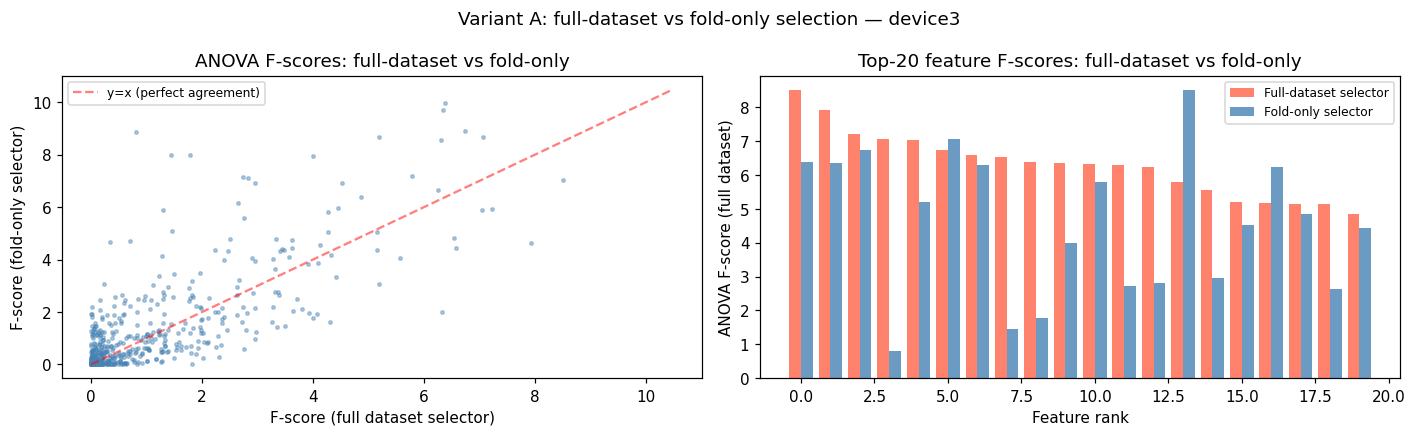

In [8]:
# Variant A demonstration: full-dataset vs fold-only feature selection
trial_info    = TRIALS_INFO[TRIALS_TO_RUN[0]]
target_device = trial_info['authorized'][0]

X_auth, y_auth, X_rogue, y_rogue = build_binary_dataset(
    X, y, device_id_mapping,
    trial_info['authorized'], target_device, trial_info['rogue']
)

K_DEMO = 20   # show top-20 features

# Leaked: fitted on full X_auth
sel_full = SelectKBest(f_classif, k=K_DEMO).fit(X_auth, y_auth)
feats_full = set(sel_full.get_support(indices=True))

# Fold-aware: fitted only on training fold of the FIRST fold
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(skf.split(X_auth, y_auth))
sel_fold = SelectKBest(f_classif, k=K_DEMO).fit(X_auth[train_idx], y_auth[train_idx])
feats_fold = set(sel_fold.get_support(indices=True))

overlap    = feats_full & feats_fold
only_full = feats_full - feats_fold
only_fold = feats_fold - feats_full

print(f'Device: {target_device}  |  k={K_DEMO} features')
print(f'  Features selected by BOTH selectors : {len(overlap)}')
print(f'  Features ONLY in full-dataset selector : {len(only_full)}')
print(f'  Features ONLY in fold-only selector    : {len(only_fold)}')
print(f'  Overlap = {len(overlap)/K_DEMO*100:.0f}% — the two selectors choose different features')

# Compare F-scores on full vs train-only
f_full,  _ = f_classif(X_auth,           y_auth)
f_train, _ = f_classif(X_auth[train_idx], y_auth[train_idx])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(f_full, f_train, s=5, alpha=0.4, color='steelblue')
lim = max(f_full.max(), f_train.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', alpha=0.5, label='y=x (perfect agreement)')
axes[0].set_xlabel('F-score (full dataset selector)')
axes[0].set_ylabel('F-score (fold-only selector)')
axes[0].set_title('ANOVA F-scores: full-dataset vs fold-only')
axes[0].legend(fontsize=8)

# Show top-K selected by each
ranks_full = np.argsort(-f_full)[:K_DEMO]
ranks_fold = np.argsort(-f_train)[:K_DEMO]
bar_labels   = [str(i) for i in range(K_DEMO)]
full_scores = f_full[ranks_full]
fold_scores = f_full[ranks_fold]   # evaluate fold-only selection using full F-score for fair comparison
x = np.arange(K_DEMO)
axes[1].bar(x - 0.2, full_scores, 0.4, label='Full-dataset selector', color='tomato',    alpha=0.8)
axes[1].bar(x + 0.2, fold_scores, 0.4, label='Fold-only selector', color='steelblue', alpha=0.8)
axes[1].set_title(f'Top-{K_DEMO} feature F-scores: full-dataset vs fold-only')
axes[1].set_xlabel('Feature rank')
axes[1].set_ylabel('ANOVA F-score (full dataset)')
axes[1].legend(fontsize=8)

plt.suptitle(f'Variant A: full-dataset vs fold-only selection — {target_device}', fontsize=12)
plt.tight_layout()
plt.show()

### Variant B — Full fold averaging
### Variant C — k selection strategy

We record the result of **every** (k, fold) combination for one device (no early break)
and show what fraction of combinations pass the 0.95 threshold.
This illustrates the sensitivity of the result to the choice of (k, fold).


In [9]:
# Full (k, fold) sweep for one device — records every result, no early break
# Limit k range for speed; the pattern is clear in the first 100 values.
print(f'Sweeping k=1..{K_SWEEP_MAX} × {N_SPLITS} folds for device {target_device}...')

auth_tvr_grid  = np.zeros((K_SWEEP_MAX, N_SPLITS))
rogue_tvr_grid = np.zeros((K_SWEEP_MAX, N_SPLITS))
pass_grid      = np.zeros((K_SWEEP_MAX, N_SPLITS), dtype=bool)

for ki, k in enumerate(range(1, K_SWEEP_MAX + 1)):
    # Variant A still present here — selector fitted on full dataset
    selector    = SelectKBest(f_classif, k=k)
    X_auth_sel  = selector.fit_transform(X_auth, y_auth)
    X_rogue_sel = X_rogue[:, selector.get_support(indices=True)]

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    for fi, (train_idx, test_idx) in enumerate(skf.split(X_auth_sel, y_auth)):
        model = SVC(kernel='poly', C=1.0)
        model.fit(X_auth_sel[train_idx], y_auth[train_idx])

        a_tvr = compute_tvr(y_auth[test_idx], model.predict(X_auth_sel[test_idx]), 1)
        r_tvr = compute_tvr(y_rogue,          model.predict(X_rogue_sel),          0)

        auth_tvr_grid[ki, fi]  = a_tvr
        rogue_tvr_grid[ki, fi] = r_tvr
        pass_grid[ki, fi]      = (a_tvr >= 0.95) and ((1 - a_tvr) <= 0.05) and \
                                  (r_tvr >= 0.95) and ((1 - r_tvr) <= 0.05)

n_passing = pass_grid.sum()
total     = K_SWEEP_MAX * N_SPLITS
print(f'\nPassing (k,fold) combinations: {n_passing} / {total} = {n_passing/total*100:.1f}%')
print(f'First passing combination: ', end='')
found = False
for ki in range(K_SWEEP_MAX):
    for fi in range(N_SPLITS):
        if pass_grid[ki, fi]:
            print(f'k={ki+1}, fold={fi+1}')
            found = True
            break
    if found:
        break
if not found:
    print('none in this range')

Sweeping k=1..100 × 5 folds for device device3...

Passing (k,fold) combinations: 0 / 500 = 0.0%
First passing combination: none in this range


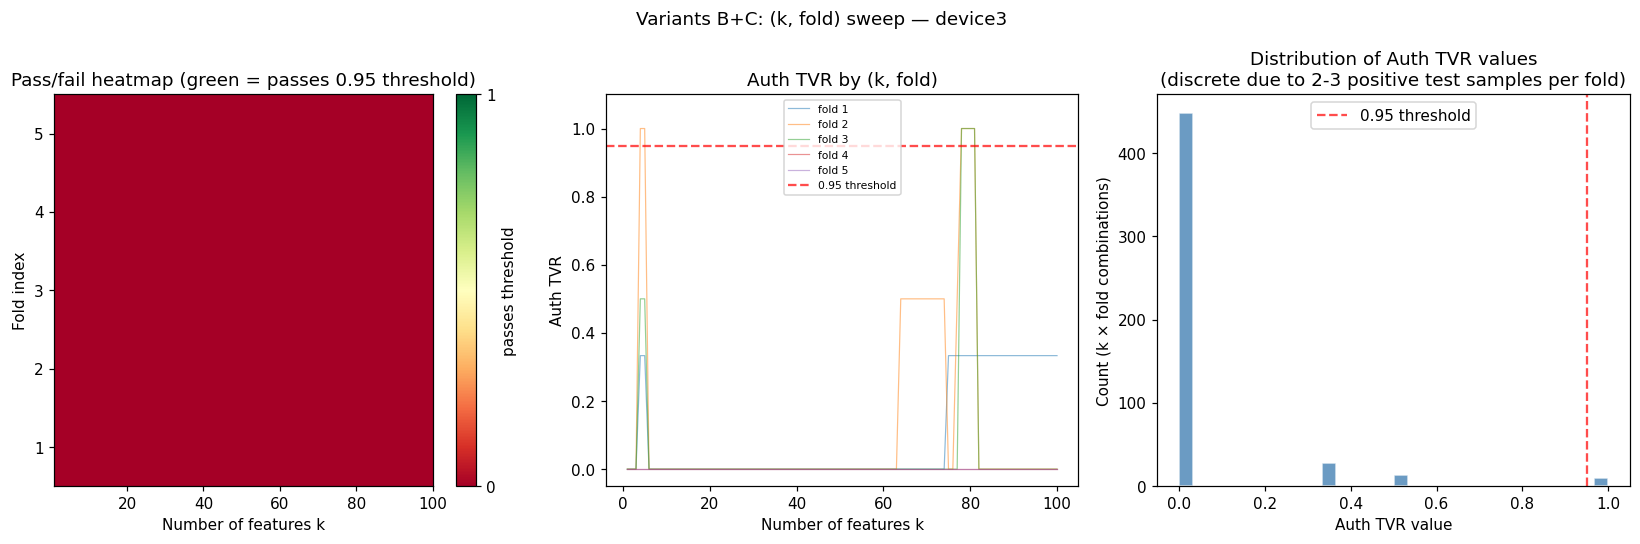


Note: 13 positive samples ÷ 5 folds ≈ 2 per test fold
→ Auth TVR can only take values: [0.0, 0.5, 1.0]


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ks    = np.arange(1, K_SWEEP_MAX + 1)
folds = np.arange(1, N_SPLITS + 1)

# Heatmap: does each (k, fold) pass?
im = axes[0].imshow(pass_grid.T, aspect='auto', cmap='RdYlGn',
                    vmin=0, vmax=1, origin='lower',
                    extent=[1, K_SWEEP_MAX, 0.5, N_SPLITS + 0.5])
axes[0].set_xlabel('Number of features k')
axes[0].set_ylabel('Fold index')
axes[0].set_yticks(folds)
axes[0].set_title('Pass/fail heatmap (green = passes 0.95 threshold)')
plt.colorbar(im, ax=axes[0], ticks=[0, 1], label='passes threshold')

# Auth TVR per k (across folds)
for fi in range(N_SPLITS):
    axes[1].plot(ks, auth_tvr_grid[:, fi], alpha=0.5, linewidth=0.8,
                 label=f'fold {fi+1}')
axes[1].axhline(0.95, color='red', linestyle='--', alpha=0.7, label='0.95 threshold')
axes[1].set_xlabel('Number of features k')
axes[1].set_ylabel('Auth TVR')
axes[1].set_title('Auth TVR by (k, fold)')
axes[1].legend(fontsize=7)
axes[1].set_ylim(-0.05, 1.10)

# Note: with 2-3 positive test samples, Auth TVR can only be 0, 0.5, or 1.0
unique_vals = np.unique(auth_tvr_grid)
axes[2].hist(auth_tvr_grid.ravel(), bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[2].set_xlabel('Auth TVR value')
axes[2].set_ylabel('Count (k × fold combinations)')
axes[2].set_title('Distribution of Auth TVR values\n(discrete due to 2-3 positive test samples per fold)')
axes[2].axvline(0.95, color='red', linestyle='--', alpha=0.7, label='0.95 threshold')
axes[2].legend()

plt.suptitle(f'Variants B+C: (k, fold) sweep — {target_device}', fontsize=12)
plt.tight_layout()
plt.show()

n_pos_per_fold = int((y_auth == 1).sum() / N_SPLITS)
print(f'\nNote: {int((y_auth==1).sum())} positive samples ÷ {N_SPLITS} folds ≈ {n_pos_per_fold} per test fold')
print(f'→ Auth TVR can only take values: {sorted(set(np.round(i/n_pos_per_fold,2) for i in range(n_pos_per_fold+1)))}')

**Reading the heatmap**: device3 shows 0 passing (k, fold) combinations out of 500.
This does not mean the original code produces no result for device3 — the original pipeline
includes a **closeness-score fallback**: when no (k, fold) strictly meets all four threshold
conditions, it stores the combination that minimises the sum of absolute deviations from the
target. Device3's reported auth TVR=1.000 in the original pipeline comes from this fallback.
The heatmap shows that the strict 0.95 threshold is never met for this device under this protocol.


## 4. Variant A — Fold-aware feature selection

**Change**: `SelectKBest` is now fitted only on the training split of each fold.
The same transform is applied to the test split and the rogue set.

Variants B and C (k-sweep and first-passing-fold reporting) remain as in the original.


In [11]:
def run_variant_a(X, y, device_id_mapping, trial_info, k_max=None):
    """Variant A: feature selection fitted inside each fold."""
    if k_max is None:
        k_max = X.shape[1]

    authorized = trial_info['authorized']
    rogue      = trial_info['rogue']
    results    = {}

    for target_device in authorized:
        X_auth, y_auth, X_rogue, y_rogue = build_binary_dataset(
            X, y, device_id_mapping, authorized, target_device, rogue
        )

        best_score  = float('inf')
        best_detail = None

        for k in range(1, k_max + 1):
            skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
            for train_idx, test_idx in skf.split(X_auth, y_auth):
                # ✓ Variant A: selector fitted only on training fold
                selector    = SelectKBest(f_classif, k=k)
                X_tr        = selector.fit_transform(X_auth[train_idx], y_auth[train_idx])
                X_te        = selector.transform(X_auth[test_idx])
                X_rogue_sel = selector.transform(X_rogue)
                y_tr        = y_auth[train_idx]
                y_te        = y_auth[test_idx]

                model = RandomForestClassifier(n_estimators=10, max_depth=8, random_state=RANDOM_STATE)
                model.fit(X_tr, y_tr)

                auth_tvr  = compute_tvr(y_te,    model.predict(X_te),        1)
                auth_fvr  = 1.0 - auth_tvr
                rogue_tvr = compute_tvr(y_rogue, model.predict(X_rogue_sel), 0)
                rogue_fvr = 1.0 - rogue_tvr

                # Variants B+C still present
                if auth_tvr >= 0.95 and auth_fvr <= 0.05 and rogue_tvr >= 0.95 and rogue_fvr <= 0.05:
                    results[target_device] = {
                        'auth_tvr': auth_tvr, 'rogue_tvr': rogue_tvr,
                        'auth_fvr': auth_fvr, 'k': k
                    }
                    break

                score = abs(auth_tvr - 0.95) + abs(auth_fvr - 0.05) + \
                        abs(rogue_tvr - 0.95) + abs(rogue_fvr - 0.05)
                if score < best_score:
                    best_score  = score
                    best_detail = {
                        'auth_tvr': auth_tvr, 'rogue_tvr': rogue_tvr,
                        'auth_fvr': auth_fvr, 'k': k
                    }

            if target_device in results:
                break

        if target_device not in results and best_detail is not None:
            results[target_device] = best_detail

    return results


print('Variant A pipeline defined.')

Variant A pipeline defined.


In [12]:
variant_a_results = {}
for trial_name in TRIALS_TO_RUN:
    print(f'\nRunning Variant A on {trial_name}...')
    res = run_variant_a(X, y, device_id_mapping, TRIALS_INFO[trial_name])
    variant_a_results[trial_name] = res
    print_results(res, f'Variant A (fold-aware selection) — {trial_name}')


Running Variant A on trial_1...

────────────────────────────────────────────────────────
  FIX 1 (selection inside fold) — trial_1
────────────────────────────────────────────────────────
  Device         Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────
  device3           1.000      0.950    0.975
  device2           1.000      0.950    0.975
  device12          1.000      0.960    0.980
  device9           1.000      0.960    0.980
  ────────────────────────────────────────────────
  AVERAGE           1.000      0.955    0.977
────────────────────────────────────────────────────────

Running Variant A on trial_2...

────────────────────────────────────────────────────────
  FIX 1 (selection inside fold) — trial_2
────────────────────────────────────────────────────────
  Device         Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────
  device10          0.500      0.976    0.738
  device6           1.000      0.952    0.

## 5. Variant A+B — Full fold averaging

**Additional change**: all 5 folds run for every k value. Results are averaged across folds.
No early exit on threshold — the best k is the one with the highest average ADR.

Variant C remains: the best k is still chosen by the average test-set ADR across folds.
Variant A+B+C removes this by fixing k a priori.


In [13]:
def run_variant_ab(X, y, device_id_mapping, trial_info, k_max=None):
    """Variant A+B: fold-aware selection + all folds averaged."""
    if k_max is None:
        k_max = X.shape[1]

    authorized = trial_info['authorized']
    rogue      = trial_info['rogue']
    results    = {}

    for target_device in authorized:
        X_auth, y_auth, X_rogue, y_rogue = build_binary_dataset(
            X, y, device_id_mapping, authorized, target_device, rogue
        )

        best_adr = -1.0
        best_detail = None

        for k in range(1, k_max + 1):
            fold_auth, fold_rogue = [], []

            skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
            for train_idx, test_idx in skf.split(X_auth, y_auth):
                # ✓ Variant A: selection inside fold
                selector    = SelectKBest(f_classif, k=k)
                X_tr        = selector.fit_transform(X_auth[train_idx], y_auth[train_idx])
                X_te        = selector.transform(X_auth[test_idx])
                X_rogue_sel = selector.transform(X_rogue)

                model = RandomForestClassifier(n_estimators=10, max_depth=8, random_state=RANDOM_STATE)
                model.fit(X_tr, y_auth[train_idx])

                fold_auth.append(compute_tvr(y_auth[test_idx], model.predict(X_te),        1))
                fold_rogue.append(compute_tvr(y_rogue,          model.predict(X_rogue_sel), 0))

            # ✓ Variant B: average all folds, no break
            mean_auth  = float(np.mean(fold_auth))
            mean_rogue = float(np.mean(fold_rogue))
            mean_adr   = (mean_auth + mean_rogue) / 2

            if mean_adr > best_adr:
                best_adr    = mean_adr
                best_detail = {
                    'auth_tvr': mean_auth, 'rogue_tvr': mean_rogue,
                    'auth_fvr': 1 - mean_auth, 'k': k
                }

        results[target_device] = best_detail

    return results


print('Variant A+B pipeline defined.')

Variant A+B pipeline defined.


In [14]:
variant_ab_results = {}
for trial_name in TRIALS_TO_RUN:
    print(f'\nRunning Variant A+B on {trial_name}...')
    res = run_variant_ab(X, y, device_id_mapping, TRIALS_INFO[trial_name])
    variant_ab_results[trial_name] = res
    print_results(res, f'Variant A+B (avg all folds) — {trial_name}')


Running Variant A+B on trial_1...

────────────────────────────────────────────────────────
  FIX 1+2 (avg all folds) — trial_1
────────────────────────────────────────────────────────
  Device         Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────
  device3           0.367      0.924    0.645
  device2           0.433      0.878    0.656
  device12          0.500      0.966    0.733
  device9           0.400      0.916    0.658
  ────────────────────────────────────────────────
  AVERAGE           0.425      0.921    0.673
────────────────────────────────────────────────────────

Running Variant A+B on trial_2...

────────────────────────────────────────────────────────
  FIX 1+2 (avg all folds) — trial_2
────────────────────────────────────────────────────────
  Device         Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────
  device10          0.100      1.000    0.550
  device6           0.683      0.913    0.798
  de

## 6. Variant A+B+C — Fixed k

**Additional change**: k is fixed to `K_FIXED` (set at the top of the notebook, default 50).
No sweep — k is chosen a priori rather than by test-set performance.

This is the fully aligned protocol: fold-aware selection, all folds averaged, single fixed k.


In [15]:
def run_variant_abc(X, y, device_id_mapping, trial_info, k=None, groups=None):
    """Variant A+B+C: fold-aware selection, all folds averaged, fixed k.

    groups : optional int array of shape (len(y),) assigning each sample a
             transient group ID. When provided, GroupKFold is used so all
             windows of one transient stay in the same fold — preventing
             windows from the same transient staying in the same fold for the windowed dataset.
    """
    if k is None:
        k = K_FIXED

    authorized  = trial_info['authorized']
    rogue       = trial_info['rogue']
    auth_labels = [device_id_mapping[d] for d in authorized]
    results     = {}

    for target_device in authorized:
        X_auth, y_auth, X_rogue, y_rogue = build_binary_dataset(
            X, y, device_id_mapping, authorized, target_device, rogue
        )

        fold_auth, fold_rogue = [], []

        if groups is not None:
            # Filter group IDs to the authorized subset (same mask as build_binary_dataset)
            auth_mask   = np.isin(y, auth_labels)
            groups_auth = groups[auth_mask]
            kf        = GroupKFold(n_splits=N_SPLITS)
            fold_iter = kf.split(X_auth, y_auth, groups=groups_auth)
        else:
            skf       = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
            fold_iter = skf.split(X_auth, y_auth)

        for train_idx, test_idx in fold_iter:
            # ✓ Variant A: selection inside fold
            selector    = SelectKBest(f_classif, k=k)
            X_tr        = selector.fit_transform(X_auth[train_idx], y_auth[train_idx])
            X_te        = selector.transform(X_auth[test_idx])
            X_rogue_sel = selector.transform(X_rogue)

            model = RandomForestClassifier(n_estimators=10, max_depth=8, random_state=RANDOM_STATE)
            model.fit(X_tr, y_auth[train_idx])

            fold_auth.append(compute_tvr(y_auth[test_idx], model.predict(X_te),        1))
            fold_rogue.append(compute_tvr(y_rogue,          model.predict(X_rogue_sel), 0))

        # ✓ Variant B: average all folds
        # Variant C: fixed k, no sweep
        results[target_device] = {
            'auth_tvr':  float(np.mean(fold_auth)),
            'rogue_tvr': float(np.mean(fold_rogue)),
            'auth_fvr':  1 - float(np.mean(fold_auth)),
            'k':         k
        }

    return results


print('Variant A+B+C pipeline defined.')

Variant A+B+C pipeline defined.


In [16]:
variant_abc_results = {}
for trial_name in TRIALS_TO_RUN:
    print(f'\nRunning Variant A+B+C on {trial_name} (k={K_FIXED})...')
    res = run_variant_abc(X, y, device_id_mapping, TRIALS_INFO[trial_name])
    variant_abc_results[trial_name] = res
    print_results(res, f'Variant A+B+C (k={K_FIXED}) — {trial_name}')


Running Variant A+B+C on trial_1 (k=50)...

────────────────────────────────────────────────────────
  Variant A+B+C (k=50) — trial_1
────────────────────────────────────────────────────────
  Device         Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────
  device3           0.100      0.910    0.505
  device2           0.133      0.868    0.501
  device12          0.000      0.970    0.485
  device9           0.000      0.908    0.454
  ────────────────────────────────────────────────
  AVERAGE           0.058      0.914    0.486
────────────────────────────────────────────────────────

Running Variant A+B+C on trial_2 (k=50)...

────────────────────────────────────────────────────────
  Variant A+B+C (k=50) — trial_2
────────────────────────────────────────────────────────
  Device         Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────
  device10          0.000      0.998    0.499
  device6           0.450      0.906  

## 7. Comparison

Side-by-side comparison of all four pipeline variants showing the progressive
ADR change as each protocol variant is applied.


In [17]:
pipeline_labels = [
    'Original\n(paper protocol)',
    'Variant A\n(fold-aware FS)',
    'Variant A+B\n(avg folds)',
    f'Variant A+B+C\n(k={K_FIXED})',
]

for trial_name in TRIALS_TO_RUN:
    all_variants = [
        original_results[trial_name],
        variant_a_results[trial_name],
        variant_ab_results[trial_name],
        variant_abc_results[trial_name],
    ]

    summaries = [summarise(r) for r in all_variants]

    print(f'\n{"="*68}')
    print(f'  Comparison — {trial_name}')
    print(f'{"="*68}')
    print(f'  {"Pipeline":<25} {"Auth TVR":>10} {"Rogue TVR":>10} {"ADR":>8}')
    print(f'  {"─"*56}')
    for label, s in zip(pipeline_labels, summaries):
        tag = label.replace('\n', ' ')
        print(f'  {tag:<25} {s["mean_auth_tvr"]:>10.3f} {s["mean_rogue_tvr"]:>10.3f} {s["mean_adr"]:>8.3f}')
    print(f'{"="*68}')


  Comparison — trial_1
  Pipeline                    Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────────────
  Original (paper protocol)      1.000      0.960    0.980
  Variant A (fold-aware FS)      1.000      0.955    0.977
  Variant A+B (avg folds)        0.425      0.921    0.673
  Variant A+B+C (k=50)           0.058      0.914    0.486

  Comparison — trial_2
  Pipeline                    Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────────────
  Original (paper protocol)      1.000      0.962    0.981
  Variant A (fold-aware FS)      0.917      0.962    0.939
  Variant A+B (avg folds)        0.292      0.972    0.632
  Variant A+B+C (k=50)           0.108      0.961    0.535

  Comparison — trial_3
  Pipeline                    Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────────────
  Original (paper protocol)      1.000      0.980    0.990
  Variant A (fold-aware FS)      0.729     

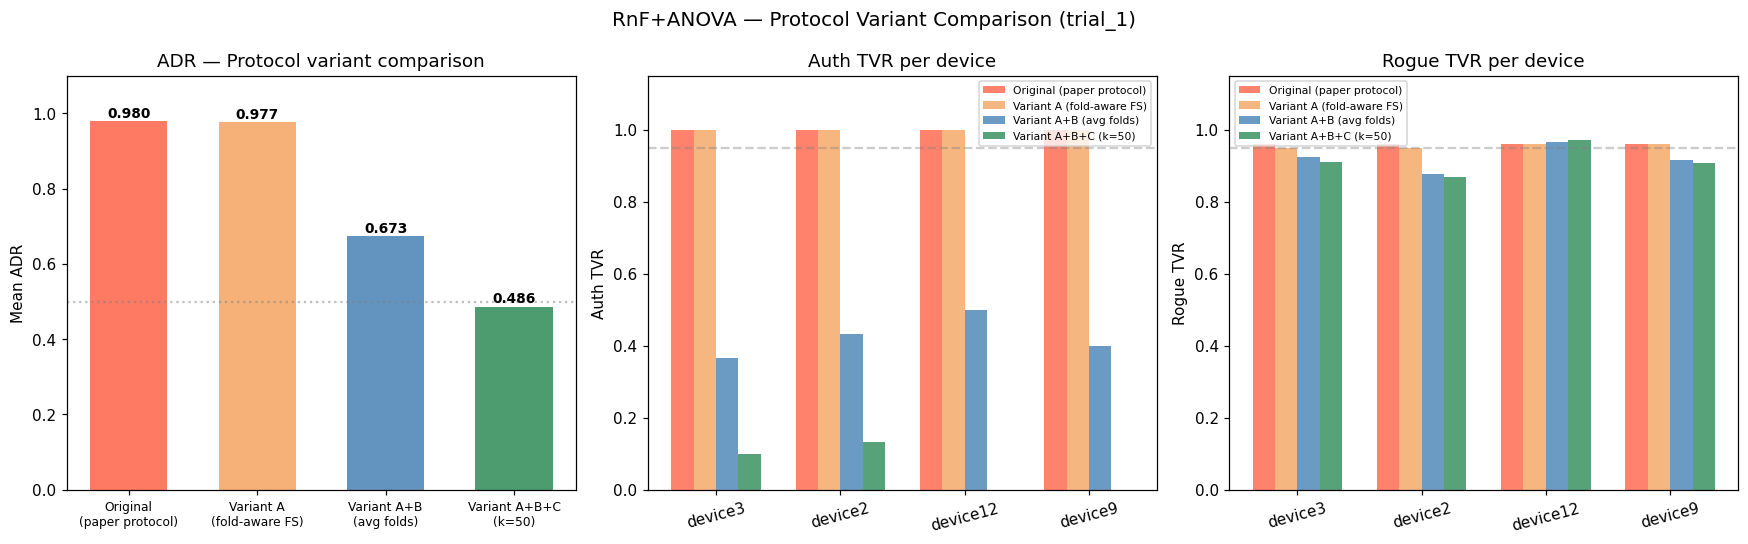

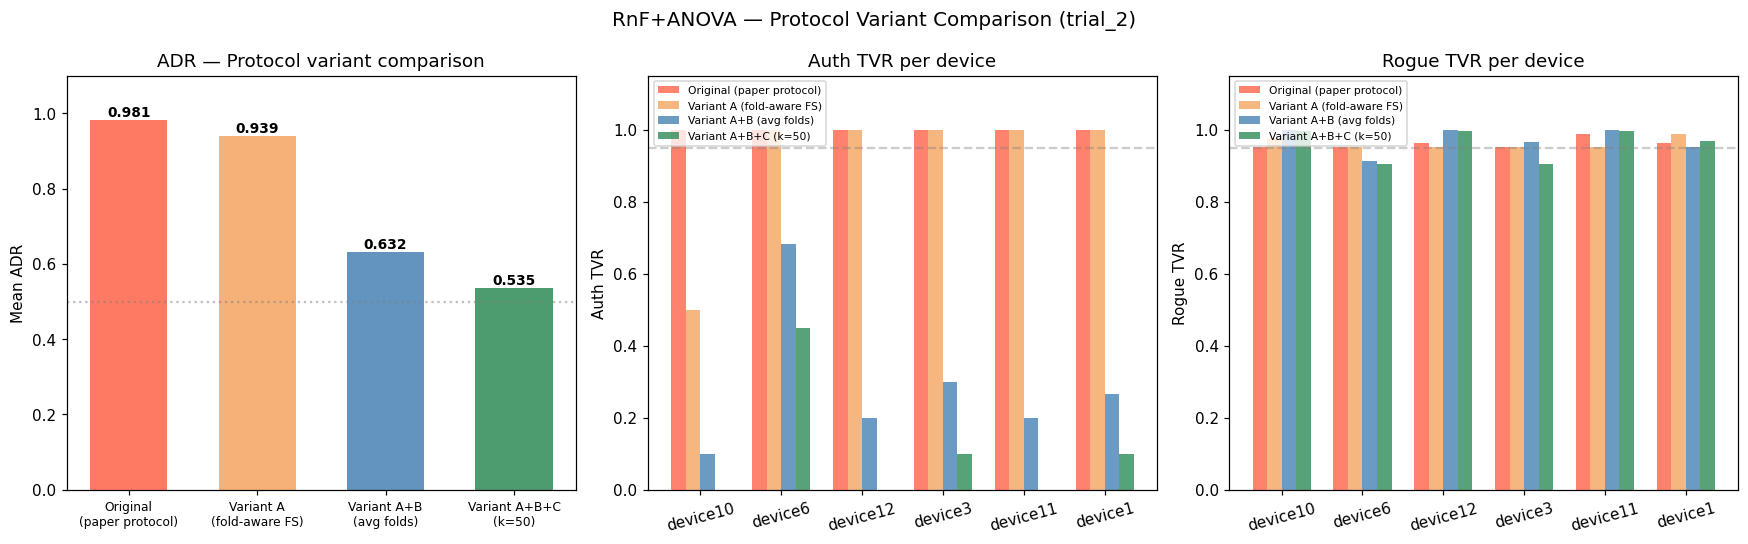

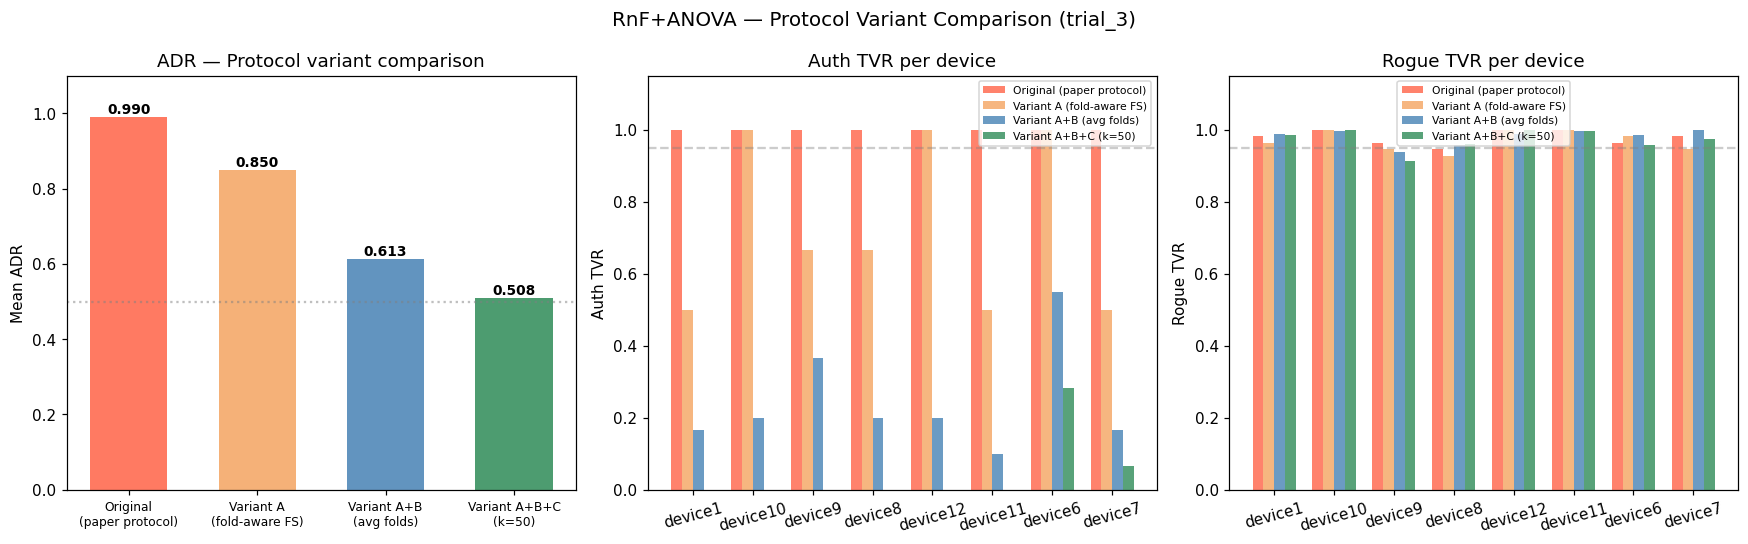

In [18]:
colors = ['tomato', 'sandybrown', 'steelblue', 'seagreen']

for trial_name in TRIALS_TO_RUN:
    all_variants = [
        original_results[trial_name],
        variant_a_results[trial_name],
        variant_ab_results[trial_name],
        variant_abc_results[trial_name],
    ]
    summaries = [summarise(r) for r in all_variants]
    devices   = list(all_variants[0].keys())

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Plot 1: mean ADR progression
    adrs = [s['mean_adr'] for s in summaries]
    bars = axes[0].bar(range(4), adrs, color=colors, alpha=0.85, width=0.6)
    axes[0].set_xticks(range(4))
    axes[0].set_xticklabels(pipeline_labels, fontsize=8)
    axes[0].set_ylim(0, 1.1)
    axes[0].set_ylabel('Mean ADR')
    axes[0].set_title('ADR — Protocol variant comparison')
    axes[0].axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='random')
    for bar, v in zip(bars, adrs):
        axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                     f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

    # Plot 2: per-device Auth TVR across pipelines
    x = np.arange(len(devices))
    width = 0.18
    for i, (variant, label, color) in enumerate(zip(all_variants, pipeline_labels, colors)):
        vals = [variant[d]['auth_tvr'] for d in devices]
        axes[1].bar(x + (i - 1.5) * width, vals, width, label=label.replace('\n', ' '),
                    color=color, alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(devices, rotation=15)
    axes[1].set_ylim(0, 1.15)
    axes[1].set_ylabel('Auth TVR')
    axes[1].set_title('Auth TVR per device')
    axes[1].axhline(0.95, color='gray', linestyle='--', alpha=0.4)
    axes[1].legend(fontsize=7)

    # Plot 3: per-device Rogue TVR across pipelines
    for i, (variant, label, color) in enumerate(zip(all_variants, pipeline_labels, colors)):
        vals = [variant[d]['rogue_tvr'] for d in devices]
        axes[2].bar(x + (i - 1.5) * width, vals, width, label=label.replace('\n', ' '),
                    color=color, alpha=0.8)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(devices, rotation=15)
    axes[2].set_ylim(0, 1.15)
    axes[2].set_ylabel('Rogue TVR')
    axes[2].set_title('Rogue TVR per device')
    axes[2].axhline(0.95, color='gray', linestyle='--', alpha=0.4)
    axes[2].legend(fontsize=7)

    plt.suptitle(f'RnF+ANOVA — Protocol Variant Comparison ({trial_name})', fontsize=13)
    plt.tight_layout()
    plt.show()

## 8. RnF+ANOVA on Windowed Data

This section applies the Variant A+B+C protocol to the windowed dataset (10 sub-sequences
per transient, ~1340 samples instead of ~134).

Two questions:
1. Does more data improve RnF+ANOVA performance?
2. How does RnF+ANOVA compare with the DL pipeline on the same data?


In [19]:
import h5py
from binary_pla.config import FV_WINDOWED_PATH

print(f'Loading windowed data from: {FV_WINDOWED_PATH}')
with h5py.File(FV_WINDOWED_PATH, 'r') as f:
    X_win = f['data'][:].astype(np.float32)
    y_win = f['labels'][:].astype(np.int64)

print(f'X_win shape: {X_win.shape}')
print(f'Samples per device:')
for label in np.unique(y_win):
    print(f'  label {label}: {(y_win == label).sum()} samples')

# Compute transient group IDs so all windows of one transient land in the same CV fold.
groups_win = np.zeros(len(y_win), dtype=np.int64)
for i, lbl in enumerate(np.unique(y_win)):
    dev_pos = np.where(y_win == lbl)[0]
    groups_win[dev_pos] = i * 10_000 + (np.arange(len(dev_pos)) // N_WINDOWS)

n_groups = len(np.unique(groups_win))
print(f'\nTransient groups computed: {n_groups} unique groups '
      f'({n_groups // len(np.unique(y_win))} transients/device on average)')
print(f'Label mapping (same as original): {device_id_mapping}')

Loading windowed data from: /Users/matteocampagnaro/Documents/Advanced-Security/processed_data/fv_windowed.h5
X_win shape: (1340, 505)
Samples per device:
  label 0: 130 samples
  label 1: 130 samples
  label 2: 130 samples
  label 3: 120 samples
  label 4: 130 samples
  label 5: 130 samples
  label 6: 130 samples
  label 7: 130 samples
  label 8: 130 samples
  label 9: 60 samples
  label 10: 60 samples
  label 11: 60 samples

Transient groups computed: 134 unique groups (11 transients/device on average)
Label mapping (same as original): {'device1': 0, 'device2': 1, 'device3': 2, 'device4': 3, 'device5': 4, 'device6': 5, 'device7': 6, 'device8': 7, 'device9': 8, 'device10': 9, 'device11': 10, 'device12': 11}


In [20]:
windowed_results = {}
for trial_name in TRIALS_TO_RUN:
    print(f'\nRunning Variant A+B+C on WINDOWED data — {trial_name}...')
    print(f'  Using GroupKFold: windows from the same transient stay in the same fold.')
    res = run_variant_abc(X_win, y_win, device_id_mapping, TRIALS_INFO[trial_name], groups=groups_win)
    windowed_results[trial_name] = res
    print_results(res, f'Variant A+B+C (k={K_FIXED}, group-aware CV) — windowed — {trial_name}')


Running Variant A+B+C on WINDOWED data — trial_1...
  Using GroupKFold: windows from the same transient stay in the same fold.

────────────────────────────────────────────────────────
  Variant A+B+C (k=50, group-aware CV) — windowed — trial_1
────────────────────────────────────────────────────────
  Device         Auth TVR  Rogue TVR      ADR
  ────────────────────────────────────────────────
  device3           0.220      0.874    0.547
  device2           0.355      0.861    0.608
  device12          0.150      0.934    0.542
  device9           0.337      0.799    0.568
  ────────────────────────────────────────────────
  AVERAGE           0.265      0.867    0.566
────────────────────────────────────────────────────────

Running Variant A+B+C on WINDOWED data — trial_2...
  Using GroupKFold: windows from the same transient stay in the same fold.

────────────────────────────────────────────────────────
  Variant A+B+C (k=50, group-aware CV) — windowed — trial_2
────────────────

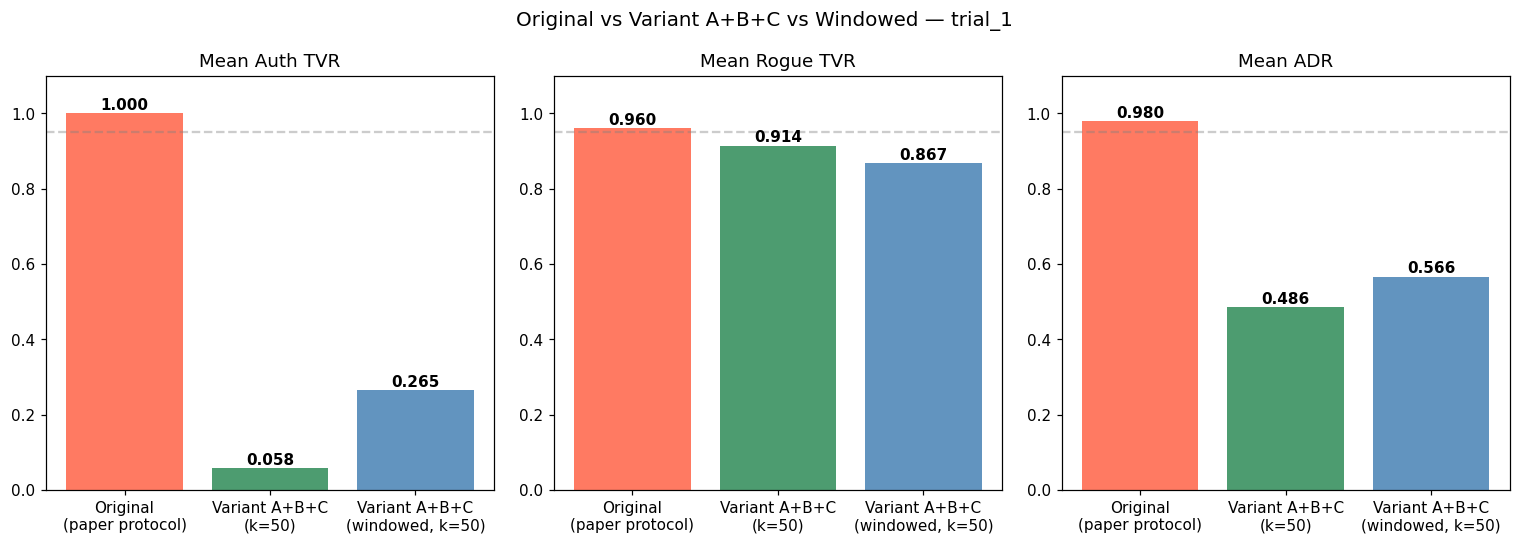


trial_1 — summary:
  Original (paper protocol, non-windowed): ADR = 0.980
  Variant A+B+C (k=50, non-windowed): ADR = 0.486
  Variant A+B+C (k=50, windowed):     ADR = 0.566
  → Protocol difference: 0.494 ADR points
  → Windowing gain (Variant A+B+C): 0.080 ADR points


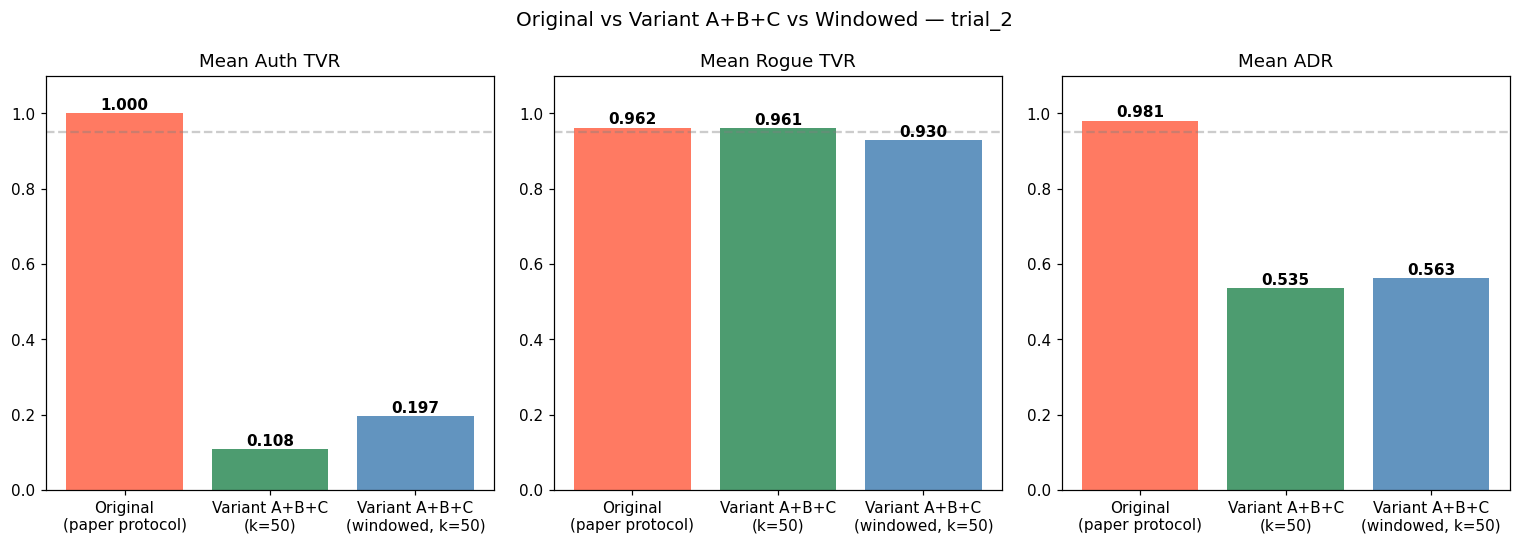


trial_2 — summary:
  Original (paper protocol, non-windowed): ADR = 0.981
  Variant A+B+C (k=50, non-windowed): ADR = 0.535
  Variant A+B+C (k=50, windowed):     ADR = 0.563
  → Protocol difference: 0.446 ADR points
  → Windowing gain (Variant A+B+C): 0.028 ADR points


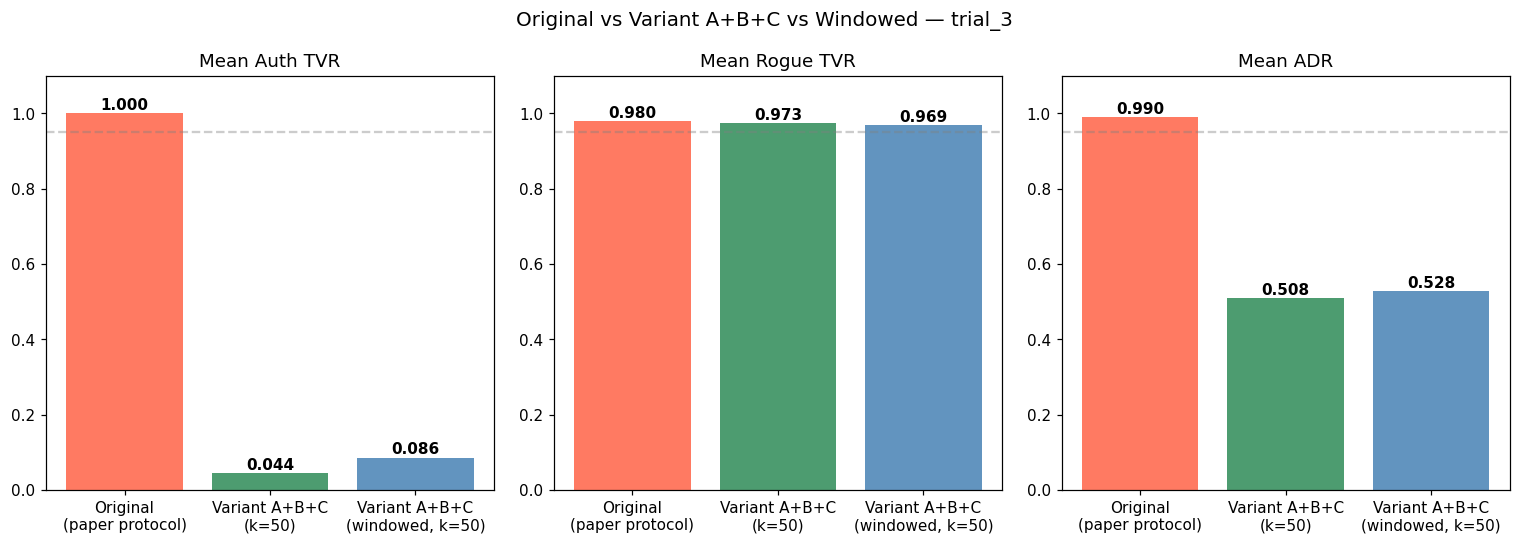


trial_3 — summary:
  Original (paper protocol, non-windowed): ADR = 0.990
  Variant A+B+C (k=50, non-windowed): ADR = 0.508
  Variant A+B+C (k=50, windowed):     ADR = 0.528
  → Protocol difference: 0.481 ADR points
  → Windowing gain (Variant A+B+C): 0.019 ADR points


In [21]:
for trial_name in TRIALS_TO_RUN:
    s_orig     = summarise(original_results[trial_name])
    s_revised = summarise(variant_abc_results[trial_name])
    s_windowed  = summarise(windowed_results[trial_name])

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    labels_cmp = ['Original\n(paper protocol)', f'Variant A+B+C\n(k={K_FIXED})', f'Variant A+B+C\n(windowed, k={K_FIXED})']
    colors_cmp = ['tomato', 'seagreen', 'steelblue']

    for ax, metric, title in [
        (axes[0], 'mean_auth_tvr',  'Mean Auth TVR'),
        (axes[1], 'mean_rogue_tvr', 'Mean Rogue TVR'),
        (axes[2], 'mean_adr',       'Mean ADR'),
    ]:
        vals = [s_orig[metric], s_revised[metric], s_windowed[metric]]
        bars = ax.bar(labels_cmp, vals, color=colors_cmp, alpha=0.85)
        ax.set_ylim(0, 1.1)
        ax.set_title(title)
        ax.axhline(0.95, color='gray', linestyle='--', alpha=0.4, label='0.95')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                    f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

    plt.suptitle(f'Original vs Variant A+B+C vs Windowed — {trial_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f'\n{trial_name} — summary:')
    print(f'  Original (paper protocol, non-windowed): ADR = {s_orig["mean_adr"]:.3f}')
    print(f'  Variant A+B+C (k={K_FIXED}, non-windowed): ADR = {s_revised["mean_adr"]:.3f}')
    print(f'  Variant A+B+C (k={K_FIXED}, windowed):     ADR = {s_windowed["mean_adr"]:.3f}')
    print(f'  → Protocol difference: {s_orig["mean_adr"] - s_revised["mean_adr"]:.3f} ADR points')
    print(f'  → Windowing gain (Variant A+B+C): {s_windowed["mean_adr"] - s_revised["mean_adr"]:.3f} ADR points')

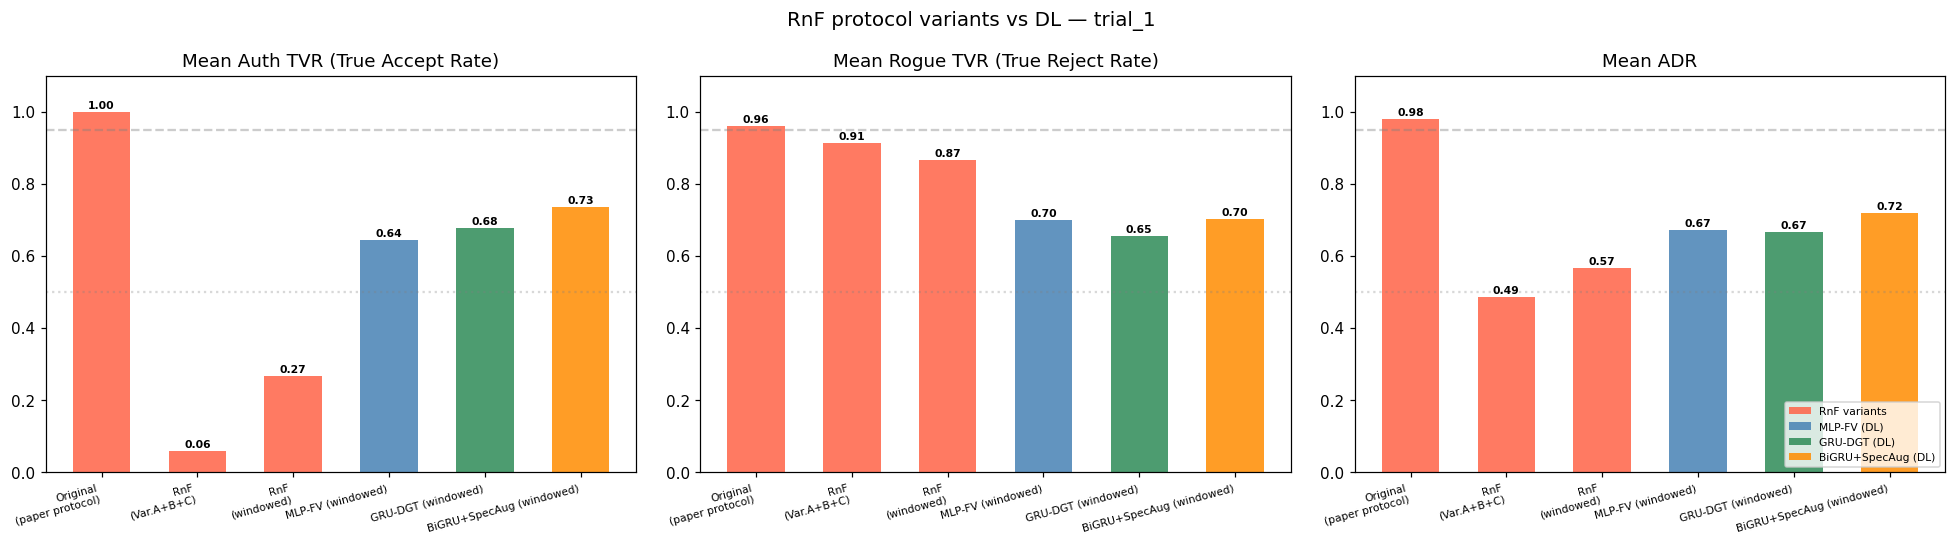


Model                           Auth TVR  Rogue TVR     ADR
────────────────────────────────────────────────────────────
Original (paper protocol)          1.000      0.960   0.980
RnF (Var.A+B+C)                    0.058      0.914   0.486
RnF (windowed)                     0.265      0.867   0.566
MLP-FV (windowed)                  0.644      0.699   0.671
GRU-DGT (windowed)                 0.677      0.654   0.665
BiGRU+SpecAug (windowed)           0.735      0.703   0.719


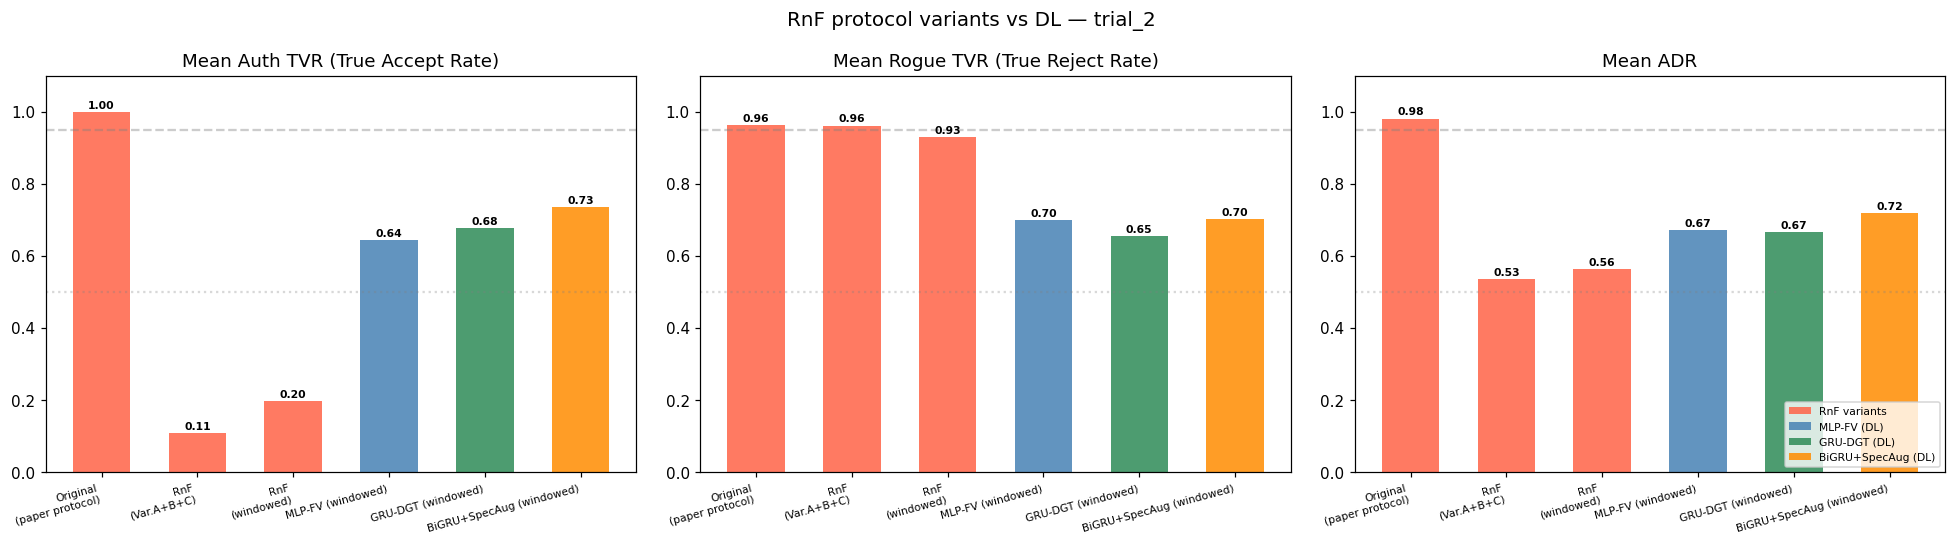


Model                           Auth TVR  Rogue TVR     ADR
────────────────────────────────────────────────────────────
Original (paper protocol)          1.000      0.962   0.981
RnF (Var.A+B+C)                    0.108      0.961   0.535
RnF (windowed)                     0.197      0.930   0.563
MLP-FV (windowed)                  0.644      0.699   0.671
GRU-DGT (windowed)                 0.677      0.654   0.665
BiGRU+SpecAug (windowed)           0.735      0.703   0.719


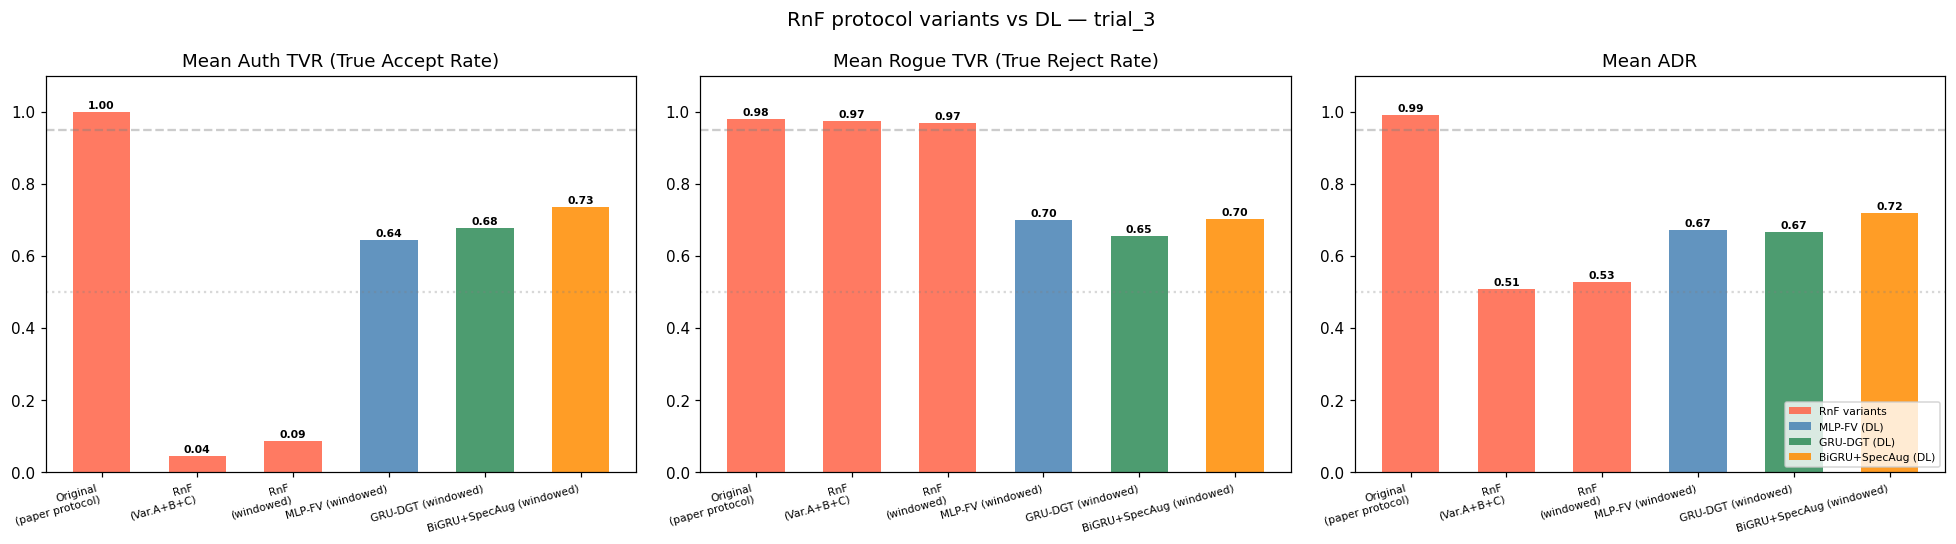


Model                           Auth TVR  Rogue TVR     ADR
────────────────────────────────────────────────────────────
Original (paper protocol)          1.000      0.980   0.990
RnF (Var.A+B+C)                    0.044      0.973   0.508
RnF (windowed)                     0.086      0.969   0.528
MLP-FV (windowed)                  0.644      0.699   0.671
GRU-DGT (windowed)                 0.677      0.654   0.665
BiGRU+SpecAug (windowed)           0.735      0.703   0.719


In [22]:
# ── DL comparison (results from notebook 01) ────────────────────────────────
# Update these values after re-running notebook 01.
DL_RESULTS = {
    'MLP-FV (windowed)':       {'auth_tvr': 0.644, 'rogue_tvr': 0.699, 'adr': 0.671},
    'GRU-DGT (windowed)':      {'auth_tvr': 0.677, 'rogue_tvr': 0.654, 'adr': 0.665},
    'BiGRU+SpecAug (windowed)':{'auth_tvr': 0.735, 'rogue_tvr': 0.703, 'adr': 0.719},
}

for trial_name in TRIALS_TO_RUN:
    s_orig     = summarise(original_results[trial_name])
    s_revised = summarise(variant_abc_results[trial_name])
    s_windowed  = summarise(windowed_results[trial_name])

    # Build labels and values including DL entries
    labels_full  = [
        'Original\n(paper protocol)',
        f'RnF\n(Var.A+B+C)',
        f'RnF\n(windowed)',
    ] + list(DL_RESULTS.keys())

    auth_vals  = [s_orig['mean_auth_tvr'],  s_revised['mean_auth_tvr'], s_windowed['mean_auth_tvr']] + \
                 [v['auth_tvr']  for v in DL_RESULTS.values()]
    rogue_vals = [s_orig['mean_rogue_tvr'], s_revised['mean_rogue_tvr'], s_windowed['mean_rogue_tvr']] + \
                 [v['rogue_tvr'] for v in DL_RESULTS.values()]
    adr_vals   = [s_orig['mean_adr'],       s_revised['mean_adr'],     s_windowed['mean_adr']] + \
                 [v['adr']       for v in DL_RESULTS.values()]

    colors_full = ['tomato'] * 3 + ['steelblue', 'seagreen', 'darkorange']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    x = np.arange(len(labels_full))

    for ax, vals, title in [
        (axes[0], auth_vals,  'Mean Auth TVR (True Accept Rate)'),
        (axes[1], rogue_vals, 'Mean Rogue TVR (True Reject Rate)'),
        (axes[2], adr_vals,   'Mean ADR'),
    ]:
        bars = ax.bar(x, vals, color=colors_full, alpha=0.85, width=0.6)
        ax.set_xticks(x)
        ax.set_xticklabels(labels_full, fontsize=7, rotation=15, ha='right')
        ax.set_ylim(0, 1.1)
        ax.set_title(title)
        ax.axhline(0.95, color='gray', linestyle='--', alpha=0.4)
        ax.axhline(0.5,  color='gray', linestyle=':',  alpha=0.3, label='random')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                    f'{v:.2f}', ha='center', fontsize=7, fontweight='bold')

    # Legend: red=SVM variants, coloured=DL models
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='tomato',     alpha=0.85, label='RnF variants'),
        Patch(facecolor='steelblue',  alpha=0.85, label='MLP-FV (DL)'),
        Patch(facecolor='seagreen',   alpha=0.85, label='GRU-DGT (DL)'),
        Patch(facecolor='darkorange', alpha=0.85, label='BiGRU+SpecAug (DL)'),
    ]
    axes[2].legend(handles=legend_elements, fontsize=7, loc='lower right')

    plt.suptitle(f'RnF protocol variants vs DL — {trial_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f'\n{"Model":<30} {"Auth TVR":>9} {"Rogue TVR":>10} {"ADR":>7}')
    print('─' * 60)
    for lbl, a, r, d in zip(labels_full, auth_vals, rogue_vals, adr_vals):
        tag = lbl.replace('\n', ' ')
        print(f'{tag:<30} {a:>9.3f} {r:>10.3f} {d:>7.3f}')

## 9. Save results


In [23]:
from binary_pla.config import NB01_ID
from binary_pla.results_io import save_results

def _build_variant(results_dict, trial):
    """Flatten per-device results for one pipeline variant into a JSON-ready dict."""
    trial_res = results_dict[trial]
    out = {}
    for dev, r in trial_res.items():
        out[dev] = {
            "auth_tvr":  float(r["auth_tvr"]),
            "rogue_tvr": float(r["rogue_tvr"]),
            "adr":       float((r["auth_tvr"] + r["rogue_tvr"]) / 2),
        }
        if "k" in r:
            out[dev]["k"] = int(r["k"])
    s = summarise(trial_res)
    out["_summary"] = {k: float(v) for k, v in s.items()}
    return out

for trial in TRIALS_TO_RUN:
    results_payload = {
        "original":          _build_variant(original_results,   trial),
        "variant_a":              _build_variant(variant_a_results,        trial),
        "variant_ab":            _build_variant(variant_ab_results,       trial),
        "variant_abc":          _build_variant(variant_abc_results,      trial),
        "windowed":          _build_variant(windowed_results,    trial),
    }
    save_results(
        NB01_ID, trial, results_payload,
        extra_meta={
            "k_fixed":      K_FIXED,
            "n_splits":     N_SPLITS,
            "random_state": RANDOM_STATE,
            "trials_run":   TRIALS_TO_RUN,
        },
    )

[results_io] saved → /Users/matteocampagnaro/Documents/Advanced-Security/results/nb01_ml_baseline_trial_1.json
[results_io] saved → /Users/matteocampagnaro/Documents/Advanced-Security/results/nb01_ml_baseline_trial_2.json
[results_io] saved → /Users/matteocampagnaro/Documents/Advanced-Security/results/nb01_ml_baseline_trial_3.json
